# 04 — Modelo de Machine Learning

**Objetivo:** Treinar um classificador para prever a **gravidade de um acidente** (sem vítimas / com feridos / fatal) com base em variáveis disponíveis no momento do registro.

Isso permite que a Prefeitura identifique *perfis de risco* e direcione recursos preventivos para os horários, locais e condições mais críticos.

---

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, ConfusionMatrixDisplay
)
from sklearn.pipeline import Pipeline

# Estilo
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
AZUL = '#1a6faf'

# Carrega dados
df = pd.read_csv('../data/processed/acidentes_niteroi_limpo.csv',
                 parse_dates=['data'], low_memory=False)
print(f'Dataset: {df.shape[0]:,} registros')

Dataset: 4,320 registros


## 1. Preparação das Features

In [2]:
# --- 1.1 Seleciona colunas potencialmente úteis ---
FEATURES_NUMERICAS = ['hora', 'dia_semana', 'mes', 'ano', 'latitude', 'longitude']
FEATURES_CATEGORICAS = [
    'causa_acidente', 'tipo_acidente', 'condicao_metereologica',
    'tipo_pista', 'fase_dia', 'tracado_via'
]
TARGET = 'gravidade'

# Filtra apenas colunas existentes
feats_num = [c for c in FEATURES_NUMERICAS if c in df.columns]
feats_cat = [c for c in FEATURES_CATEGORICAS if c in df.columns]
todas_feats = feats_num + feats_cat

print(f'Features numéricas:   {feats_num}')
print(f'Features categóricas: {feats_cat}')

# Filtra linhas com target válido
df_ml = df[todas_feats + [TARGET]].dropna(subset=[TARGET])
print(f'\nRegistros para ML: {len(df_ml):,}')
print(f'Distribuição do target:')
print(df_ml[TARGET].value_counts())

Features numéricas:   ['hora', 'dia_semana', 'mes', 'ano', 'latitude', 'longitude']
Features categóricas: ['causa_acidente', 'tipo_acidente', 'condicao_metereologica', 'tipo_pista', 'fase_dia', 'tracado_via']

Registros para ML: 4,320
Distribuição do target:
gravidade
1.0    3481
0.0     652
2.0     187
Name: count, dtype: int64


In [3]:
# --- 1.2 Encoding das variáveis categóricas ---
df_encoded = df_ml.copy()
encoders = {}

for col in feats_cat:
    le = LabelEncoder()
    df_encoded[col] = df_encoded[col].fillna('DESCONHECIDO')
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    encoders[col] = le

# Preenche nulos numéricos com mediana
for col in feats_num:
    df_encoded[col] = df_encoded[col].fillna(df_encoded[col].median())

X = df_encoded[todas_feats]
y = df_encoded[TARGET].astype(int)

print(f'Shape de X: {X.shape}')
print(f'Classes: {sorted(y.unique())}')

Shape de X: (4320, 12)
Classes: [0, 1, 2]


## 2. Divisão Treino / Teste

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Treino: {len(X_train):,} | Teste: {len(X_test):,}')
print(f'Proporção no treino:')
print(y_train.value_counts(normalize=True).round(3))

Treino: 3,456 | Teste: 864
Proporção no treino:
gravidade
1    0.806
0    0.151
2    0.043
Name: proportion, dtype: float64


## 3. Treinamento — Random Forest

In [5]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',   # importante: classes desbalanceadas
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
print('Modelo treinado!')

# Cross-validation
cv_scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
print(f'Cross-val Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

Modelo treinado!
Cross-val Accuracy: 0.757 ± 0.022


## 4. Avaliação do Modelo

In [6]:
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'Acurácia no teste: {acc:.3f}\n')

classes_nomes = ['Sem Vítimas', 'Com Feridos', 'Fatal']
classes_presentes = sorted(y.unique())

print(classification_report(
    y_test, y_pred,
    target_names=[classes_nomes[i] for i in classes_presentes]
))

Acurácia no teste: 0.736

              precision    recall  f1-score   support

 Sem Vítimas       0.33      0.39      0.36       130
 Com Feridos       0.86      0.83      0.84       696
       Fatal       0.24      0.21      0.22        38

    accuracy                           0.74       864
   macro avg       0.47      0.48      0.47       864
weighted avg       0.75      0.74      0.74       864



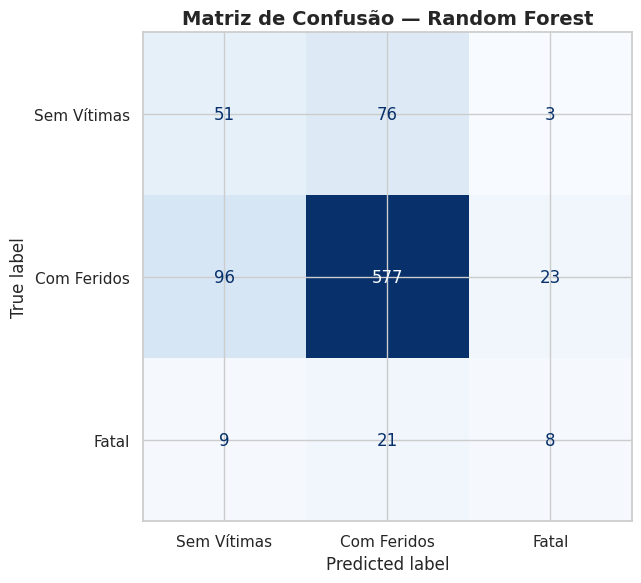

In [7]:
# Matriz de confusão
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred),
    display_labels=[classes_nomes[i] for i in classes_presentes]
)
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title('Matriz de Confusão — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/matriz_confusao.png', dpi=150)
plt.show()

## 5. Importância das Features

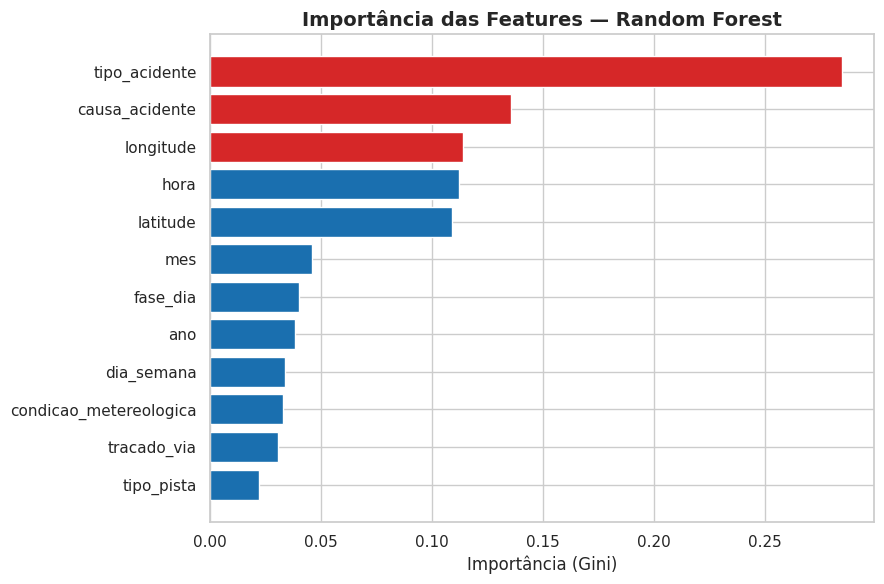

Top 3 features mais importantes:
  tipo_acidente: 0.2848
  causa_acidente: 0.1354
  longitude: 0.1141


In [8]:
importancias = pd.Series(rf.feature_importances_, index=todas_feats)
importancias = importancias.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d62728' if v > importancias.quantile(0.75) else AZUL
          for v in importancias.values]
bars = ax.barh(importancias.index, importancias.values, color=colors)
ax.set_title('Importância das Features — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

print('Top 3 features mais importantes:')
for feat, val in importancias.sort_values(ascending=False).head(3).items():
    print(f'  {feat}: {val:.4f}')

## 6. Comparação com Regressão Logística

Regressão Logística — Acurácia: 0.476
Random Forest       — Acurácia: 0.736


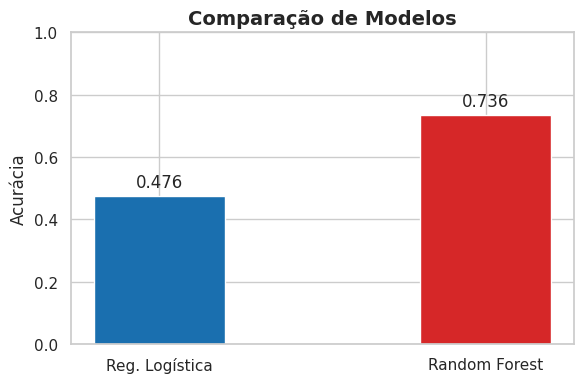

In [9]:
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

pipe_lr.fit(X_train, y_train)
acc_lr = accuracy_score(y_test, pipe_lr.predict(X_test))

print(f'Regressão Logística — Acurácia: {acc_lr:.3f}')
print(f'Random Forest       — Acurácia: {acc:.3f}')

# Gráfico comparativo
fig, ax = plt.subplots(figsize=(6, 4))
modelos = ['Reg. Logística', 'Random Forest']
acuracias = [acc_lr, acc]
bars = ax.bar(modelos, acuracias, color=[AZUL, '#d62728'], width=0.4)
ax.bar_label(bars, fmt='{:.3f}', padding=3)
ax.set_ylim(0, 1)
ax.set_title('Comparação de Modelos', fontsize=14, fontweight='bold')
ax.set_ylabel('Acurácia')
plt.tight_layout()
plt.savefig('../outputs/comparacao_modelos.png', dpi=150)
plt.show()

## 7. Conclusões do Modelo

> *(Preencha após executar com os dados reais)*

In [10]:
print('=== RESUMO DO MODELO ===')
print(f'Algoritmo:        Random Forest (200 árvores)')
print(f'Acurácia (teste): {acc:.1%}')
print(f'Cross-val:        {cv_scores.mean():.1%} ± {cv_scores.std():.1%}')
print()
top_feature = importancias.sort_values(ascending=False).index[0]
print(f'Feature mais preditiva: {top_feature}')
print()
print('Interpretação:')
print('- O modelo pode ser usado para alertar sobre condições de alto risco')
print('- As features mais importantes guiam onde a Prefeitura deve intervir')
print('- Limitação: classe "Fatal" é rara (desbalanceamento), métricas de F1 são mais relevantes que acurácia bruta')

=== RESUMO DO MODELO ===
Algoritmo:        Random Forest (200 árvores)
Acurácia (teste): 73.6%
Cross-val:        75.7% ± 2.2%

Feature mais preditiva: tipo_acidente

Interpretação:
- O modelo pode ser usado para alertar sobre condições de alto risco
- As features mais importantes guiam onde a Prefeitura deve intervir
- Limitação: classe "Fatal" é rara (desbalanceamento), métricas de F1 são mais relevantes que acurácia bruta
